In this notebook I exmplored the DEM file (elevation) and the binary mask used in DHSVM. The output is a shapefile that only incldues the elevations > 3520 ft, which is the elevation of the lowest SNOTEL station.

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Check the file header
with open('/data0/hernanqd/instance_2021_data/instance_2021_DHSVM_3.1.3/arc/demsrtm150f.asc') as f:
    for i in range(10):
        print(f"Line {i}: {f.readline().strip()}")


Line 0: -9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-9999.000000	-999

Shape: (1020, 916)
Data type: float64
Min elevation: -9999.00
Max elevation: 3267.90


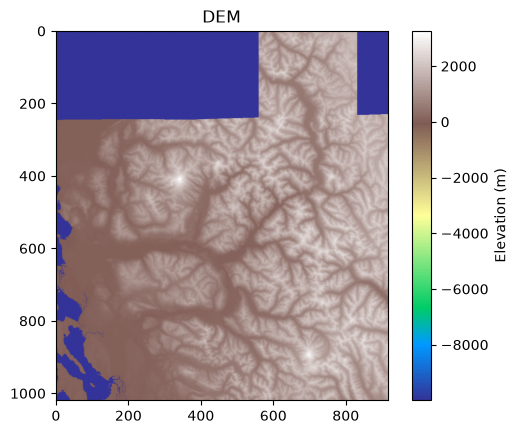

In [6]:
import numpy as np

# Read the raw ASCII grid data (no header)
data = np.loadtxt('/data0/hernanqd/instance_2021_data/instance_2021_DHSVM_3.1.3/arc/demsrtm150f.asc')

print(f"Shape: {data.shape}")
print(f"Data type: {data.dtype}")
print(f"Min elevation: {np.nanmin(data):.2f}")
print(f"Max elevation: {np.nanmax(data):.2f}")

# Visualize
import matplotlib.pyplot as plt
plt.imshow(data, cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.title('DEM')
plt.show()


In [8]:
import numpy as np
import os

# Check file size to determine data type
file_size = os.path.getsize('/data0/hernanqd/instance_2021_data/instance_2021_DHSVM_3.1.3/arc/skagit.mask.bin')
print(f"File size: {file_size} bytes")

# Determine data type based on file size
for dtype_name, dtype in [('float32', np.float32), ('float64', np.float64), ('int32', np.int32), ('uint8', np.uint8)]:
    n_elements = file_size / np.dtype(dtype).itemsize
    print(f"{dtype_name}: {n_elements} elements")
    
    # Check if it makes a square or rectangular grid
    sqrt_n = int(np.sqrt(n_elements))
    if sqrt_n * sqrt_n == n_elements:
        print(f"  → Could be {sqrt_n}×{sqrt_n}")
    
    # Check common divisors
    for h in [256, 512, 1024, 2048, 483]:
        if n_elements % h == 0:
            w = int(n_elements / h)
            print(f"  → Could be {h}×{w}")


File size: 934320 bytes
float32: 233580.0 elements
float64: 116790.0 elements
int32: 233580.0 elements
uint8: 934320.0 elements


Mask shape: (1020, 916)
Mask unique values: [0 1]


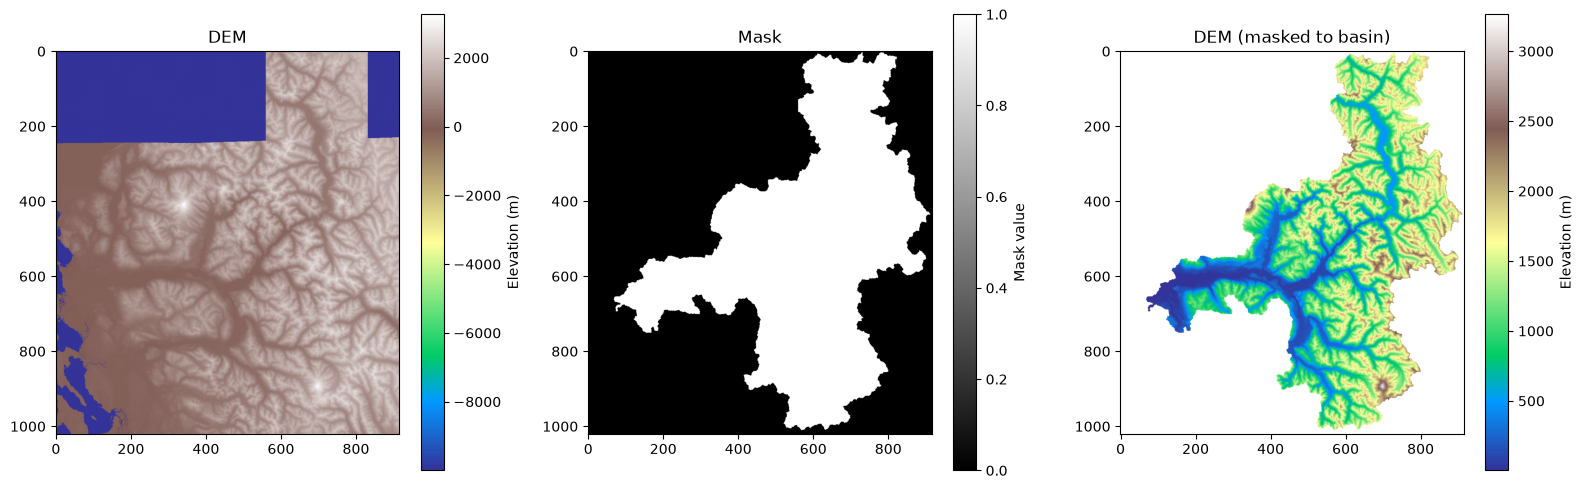

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Load DEM
dem = np.loadtxt('/data0/hernanqd/instance_2021_data/instance_2021_DHSVM_3.1.3/arc/demsrtm150f.asc')

# Load mask as uint8
mask = np.fromfile('/data0/hernanqd/instance_2021_data/instance_2021_DHSVM_3.1.3/arc/skagit.mask.bin', 
                    dtype=np.uint8).reshape(dem.shape)

print(f"Mask shape: {mask.shape}")
print(f"Mask unique values: {np.unique(mask)}")

# Visualize both
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im0 = axes[0].imshow(dem, cmap='terrain')
axes[0].set_title('DEM')
plt.colorbar(im0, ax=axes[0], label='Elevation (m)')

im1 = axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Mask')
plt.colorbar(im1, ax=axes[1], label='Mask value')

# DEM masked by mask (0 = outside basin)
dem_masked = np.ma.masked_where(mask == 0, dem)
im2 = axes[2].imshow(dem_masked, cmap='terrain')
axes[2].set_title('DEM (masked to basin)')
plt.colorbar(im2, ax=axes[2], label='Elevation (m)')

plt.tight_layout()
plt.show()

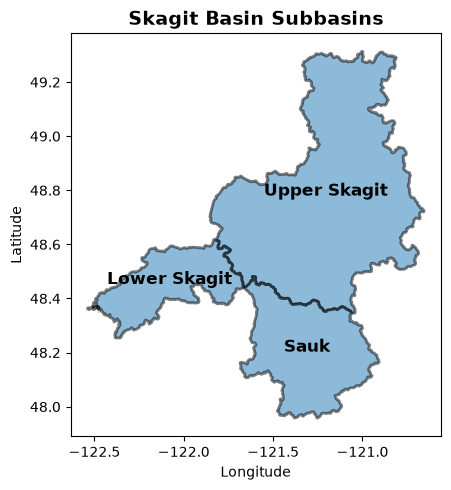

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load and filter
BASE_DIR = "/data0/hernanqd/plots_code/skagit_basin_de"
HUC8_GEO = f"{BASE_DIR}/data/GIS/SkagitSubBasin_HUC8.geojson"

gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
subbasins = ["Upper Skagit", "Sauk", "Lower Skagit"]
gdf_filtered = gdf[gdf['Name'].str.contains('|'.join(subbasins), case=False)]

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
gdf_filtered.plot(ax=ax, alpha=0.5, edgecolor='black', linewidth=2)

# Add labels
for idx, row in gdf_filtered.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['Name'], xy=(centroid.x, centroid.y),
                ha='center', fontweight='bold', fontsize=12)

ax.set_title('Skagit Basin Subbasins', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()


Basin bounds: [-122.53868336   47.95752129 -120.65460935   49.31339965]
DEM shape: (1020, 916)
Mask shape: (1020, 916)
Mask unique values: [0 1]


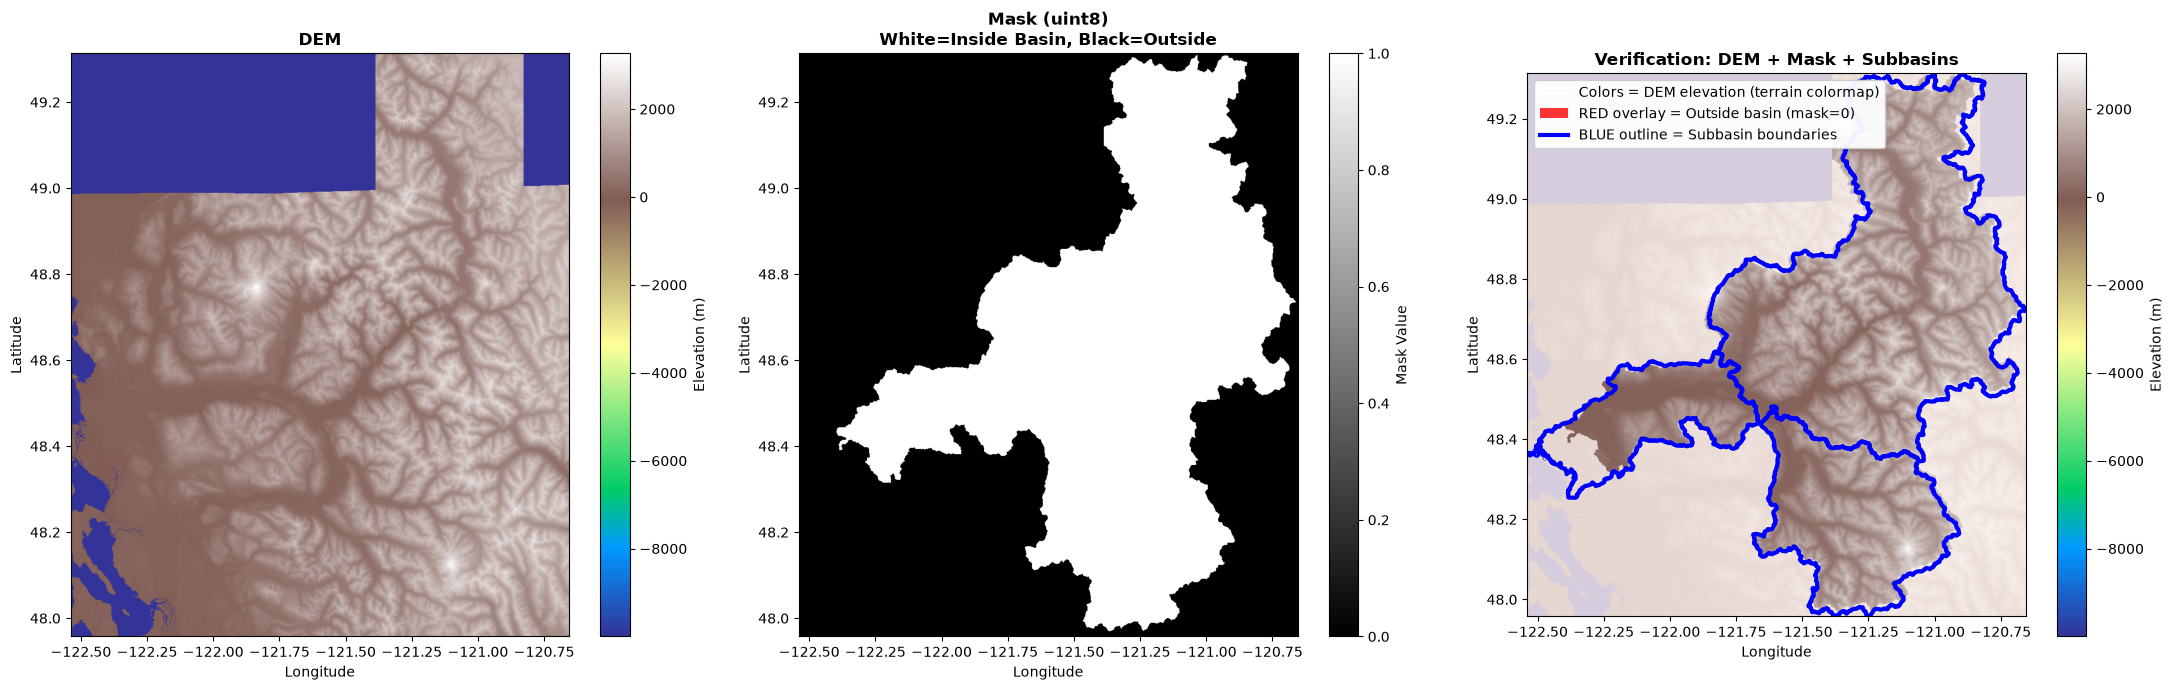


📊 BREAKDOWN:
   • Light blue INSIDE shapefile = LOW elevation from DEM (terrain colormap)
   • Brown INSIDE shapefile = HIGH elevation from DEM (terrain colormap)
   • RED overlay OUTSIDE shapefile = Areas where mask == 0 (outside basin)
   • BLUE outline = Upper Skagit, Sauk, Lower Skagit subbasin boundaries

✓ If red aligns with black areas in the middle plot, georeferencing is correct!


In [25]:
import geopandas as gpd
import rasterio
from rasterio.transform import from_bounds
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Load shapefile
BASE_DIR = "/data0/hernanqd/plots_code/skagit_basin_de"
HUC8_GEO = f"{BASE_DIR}/data/GIS/SkagitSubBasin_HUC8.geojson"
gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
subbasins = ["Upper Skagit", "Sauk", "Lower Skagit"]
gdf_filtered = gdf[gdf['Name'].str.contains('|'.join(subbasins), case=False)]

# Get bounds from shapefile
bounds = gdf_filtered.total_bounds  # [minx, miny, maxx, maxy]
print(f"Basin bounds: {bounds}")

# Load DEM and mask
dem = np.loadtxt('/data0/hernanqd/instance_2021_data/instance_2021_DHSVM_3.1.3/arc/demsrtm150f.asc')
mask = np.fromfile('/data0/hernanqd/instance_2021_data/instance_2021_DHSVM_3.1.3/arc/skagit.mask.bin',
                    dtype=np.uint8).reshape(dem.shape)

print(f"DEM shape: {dem.shape}")
print(f"Mask shape: {mask.shape}")
print(f"Mask unique values: {np.unique(mask)}")

# Create coordinate arrays using shapefile bounds
nrows, ncols = dem.shape
lons = np.linspace(bounds[0], bounds[2], ncols)
lats = np.linspace(bounds[3], bounds[1], nrows)

extent = [bounds[0], bounds[2], bounds[1], bounds[3]]

# Plot: DEM, Mask, and combined with shapefile overlay
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Plot 1: DEM only
im0 = axes[0].imshow(dem, cmap='terrain', extent=extent, origin='upper', aspect='auto')
plt.colorbar(im0, ax=axes[0], label='Elevation (m)')
axes[0].set_title('DEM', fontsize=12, fontweight='bold')

# Plot 2: Mask only
im1 = axes[1].imshow(mask, cmap='gray', extent=extent, origin='upper', aspect='auto')
plt.colorbar(im1, ax=axes[1], label='Mask Value')
axes[1].set_title('Mask (uint8)\nWhite=Inside Basin, Black=Outside', fontsize=12, fontweight='bold')

# Plot 3: DEM with mask overlay and shapefile
im2 = axes[2].imshow(dem, cmap='terrain', extent=extent, origin='upper', aspect='auto')

# Overlay mask with HIGH alpha so red is very visible where mask == 0 (outside basin)
mask_outside = np.ma.masked_where(mask != 0, mask)
axes[2].imshow(mask_outside, cmap='Reds', alpha=0.8, extent=extent, origin='upper', aspect='auto')

plt.colorbar(im2, ax=axes[2], label='Elevation (m)')

# Overlay shapefile (borders only, no facecolor)
gdf_filtered.plot(ax=axes[2], facecolor='none', edgecolor='blue', linewidth=3)
axes[2].set_title('Verification: DEM + Mask + Subbasins', fontsize=12, fontweight='bold')

# Add legend to plot 3
legend_elements = [
    Line2D([0], [0], color='w', linewidth=2.5, label='Colors = DEM elevation (terrain colormap)'),
    Patch(facecolor='red', alpha=0.8, label='RED overlay = Outside basin (mask=0)'),
    Line2D([0], [0], color='blue', linewidth=3, label='BLUE outline = Subbasin boundaries'),
]
axes[2].legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.95)

# Set labels for all
for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

print("\n📊 BREAKDOWN:")
print("   • Light blue INSIDE shapefile = LOW elevation from DEM (terrain colormap)")
print("   • Brown INSIDE shapefile = HIGH elevation from DEM (terrain colormap)")
print("   • RED overlay OUTSIDE shapefile = Areas where mask == 0 (outside basin)")
print("   • BLUE outline = Upper Skagit, Sauk, Lower Skagit subbasin boundaries")
print("\n✓ If red aligns with black areas in the middle plot, georeferencing is correct!")

Elevation threshold: 3520 ft = 1072.90 m
Pixels inside basin: 358233
Pixels above elevation threshold: 347541
Pixels meeting both criteria: 198306
DEM elevation range: -9999 - 3268 m

Converting raster mask to vector polygons...
Transform: | 0.00, 0.00,-122.54|
| 0.00,-0.00, 49.31|
| 0.00, 0.00, 1.00|
Created 75 polygons
After dissolving: 1 feature(s)
Shapefile bounds (minx, miny, maxx, maxy): [-122.18284842   47.96948492 -120.6607799    49.30941178]

✓ Shapefile saved to: /data0/hernanqd/plots_code/skagit_basin_de/data/GIS/skagit_elevation_3520ft.shp


/tmp/ipykernel_350037/960466430.py:55: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_elevation_dissolved.to_file(output_shapefile)
/home/hernanqd/.conda/envs/datasets_analysis/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'elevation_mask' to 'elevation_'
  ogr_write(


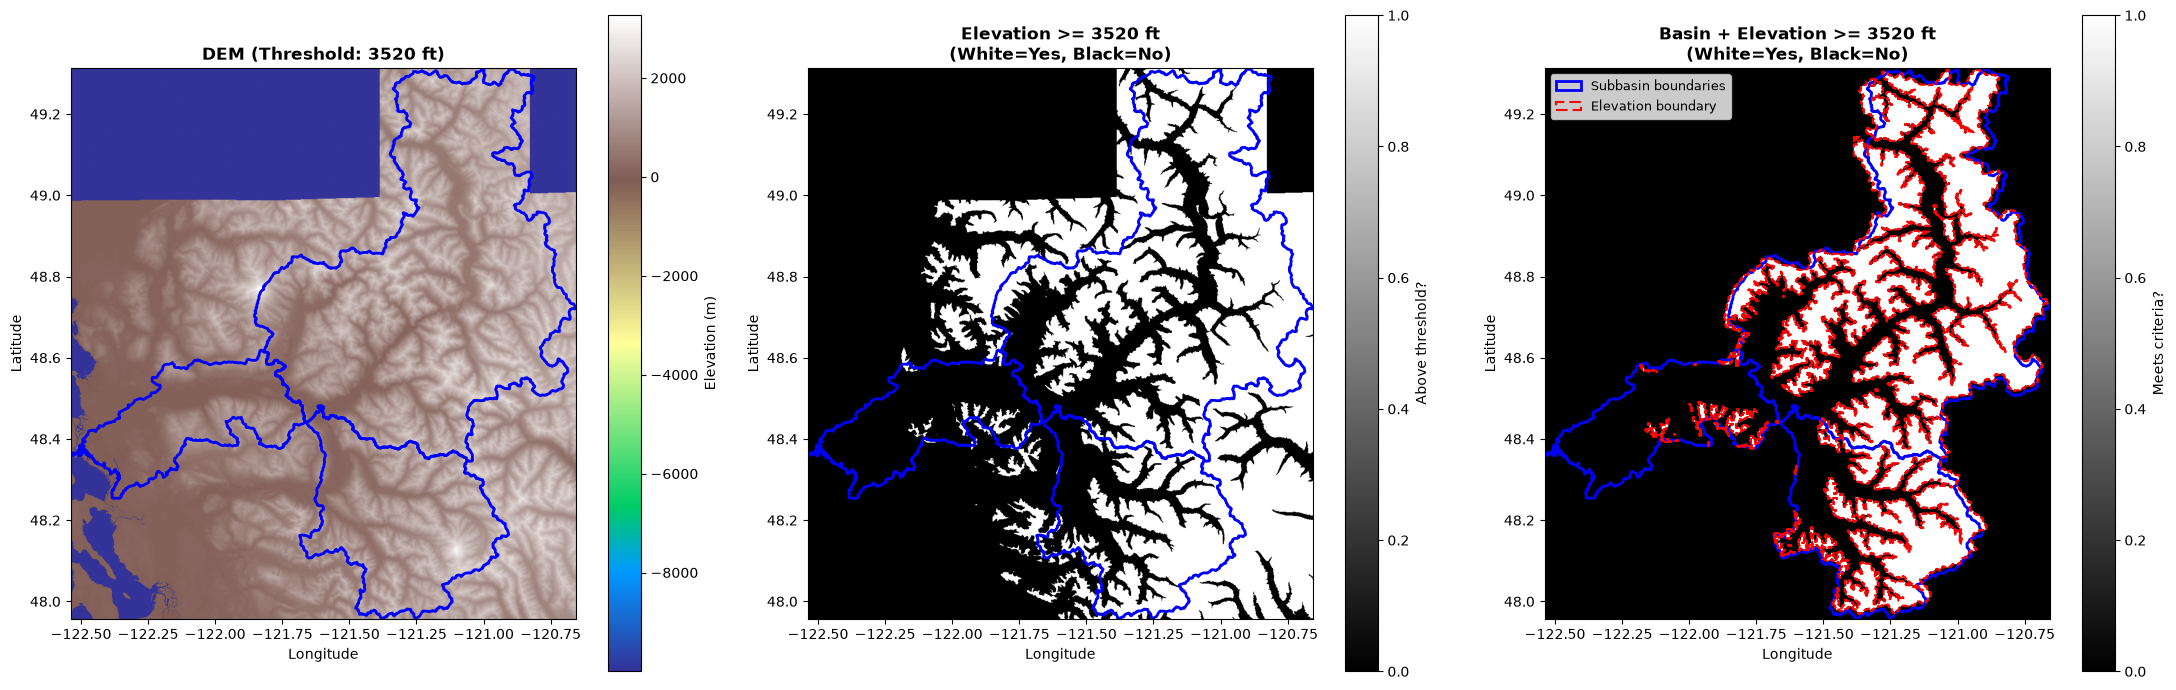


✓ Elevation-filtered mask created and saved as shapefile!
  GeoDataFrame 'gdf_elevation_dissolved' available for further analysis


In [34]:
# Create elevation-filtered mask for the Skagit basins
from rasterio import features
from rasterio.transform import from_bounds
from shapely.geometry import shape
import geopandas as gpd

elevation_threshold_ft = 3520  # feet
elevation_threshold = elevation_threshold_ft * 0.3048  # convert to meters

# Create mask: (1) inside basin AND (2) elevation >= threshold
elevation_mask = dem >= elevation_threshold
combined_mask = (mask == 1) & elevation_mask

print(f"Elevation threshold: {elevation_threshold_ft} ft = {elevation_threshold:.2f} m")
print(f"Pixels inside basin: {(mask == 1).sum()}")
print(f"Pixels above elevation threshold: {elevation_mask.sum()}")
print(f"Pixels meeting both criteria: {combined_mask.sum()}")
print(f"DEM elevation range: {np.nanmin(dem):.0f} - {np.nanmax(dem):.0f} m")

# Convert raster mask to vector polygons with CORRECT georeference
print("\nConverting raster mask to vector polygons...")
combined_mask_int = combined_mask.astype(np.uint8)

# IMPORTANT: from_bounds needs (left, bottom, right, top) = (minx, miny, maxx, maxy)
# bounds is [minx, miny, maxx, maxy] so use it directly
nrows, ncols = combined_mask_int.shape
transform = from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], ncols, nrows)
print(f"Transform: {transform}")

# Create geometries from the raster
shapes_gen = features.shapes(combined_mask_int, transform=transform)

# Collect geometries where value == 1 (inside basin and above elevation)
geometries = []
for geom, value in shapes_gen:
    if value == 1:
        geometries.append(shape(geom))

print(f"Created {len(geometries)} polygons")

# Create GeoDataFrame
gdf_elevation = gpd.GeoDataFrame(
    {'elevation_mask': [1] * len(geometries)},
    geometry=geometries,
    crs="EPSG:4326"
)

# Dissolve to merge adjacent polygons
gdf_elevation_dissolved = gdf_elevation.dissolve(by='elevation_mask', as_index=False)
print(f"After dissolving: {len(gdf_elevation_dissolved)} feature(s)")
print(f"Shapefile bounds (minx, miny, maxx, maxy): {gdf_elevation_dissolved.total_bounds}")

# Save as shapefile
output_shapefile = '/data0/hernanqd/plots_code/skagit_basin_de/data/GIS/skagit_elevation_3520ft.shp'
gdf_elevation_dissolved.to_file(output_shapefile)
print(f"\n✓ Shapefile saved to: {output_shapefile}")

# Visualization: show DEM, elevation threshold, and combined mask
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Plot 1: DEM with basin boundaries
im0 = axes[0].imshow(dem, cmap='terrain', extent=extent, origin='upper', aspect='auto')
plt.colorbar(im0, ax=axes[0], label='Elevation (m)')
axes[0].set_title(f'DEM (Threshold: {elevation_threshold_ft} ft)', fontsize=12, fontweight='bold')
gdf_filtered.plot(ax=axes[0], facecolor='none', edgecolor='blue', linewidth=2)

# Plot 2: Elevation mask (white = above threshold, black = below)
im1 = axes[1].imshow(elevation_mask.astype(int), cmap='gray', extent=extent, origin='upper', aspect='auto')
plt.colorbar(im1, ax=axes[1], label='Above threshold?')
axes[1].set_title(f'Elevation >= {elevation_threshold_ft} ft\n(White=Yes, Black=No)', fontsize=12, fontweight='bold')
gdf_filtered.plot(ax=axes[1], facecolor='none', edgecolor='blue', linewidth=2)

# Plot 3: Combined mask (basin AND elevation) with shapefile overlay
im2 = axes[2].imshow(combined_mask.astype(int), cmap='gray', extent=extent, origin='upper', aspect='auto')
plt.colorbar(im2, ax=axes[2], label='Meets criteria?')
axes[2].set_title(f'Basin + Elevation >= {elevation_threshold_ft} ft\n(White=Yes, Black=No)', fontsize=12, fontweight='bold')
gdf_filtered.plot(ax=axes[2], facecolor='none', edgecolor='blue', linewidth=2, label='Subbasin boundaries')
gdf_elevation_dissolved.plot(ax=axes[2], facecolor='none', edgecolor='red', linewidth=1.5, linestyle='--', label='Elevation boundary')
axes[2].legend(loc='upper left', fontsize=9)

# Set labels
for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

print("\n✓ Elevation-filtered mask created and saved as shapefile!")
print(f"  GeoDataFrame 'gdf_elevation_dissolved' available for further analysis")

In [35]:
new_shapefile = gpd.read_file('/data0/hernanqd/plots_code/skagit_basin_de/data/GIS/skagit_elevation_3520ft.shp')
new_shapefile

,elevation_,geometry
0,1,"MULTIPOLYGON (((-121.92369 48.38954, -121.9257..."


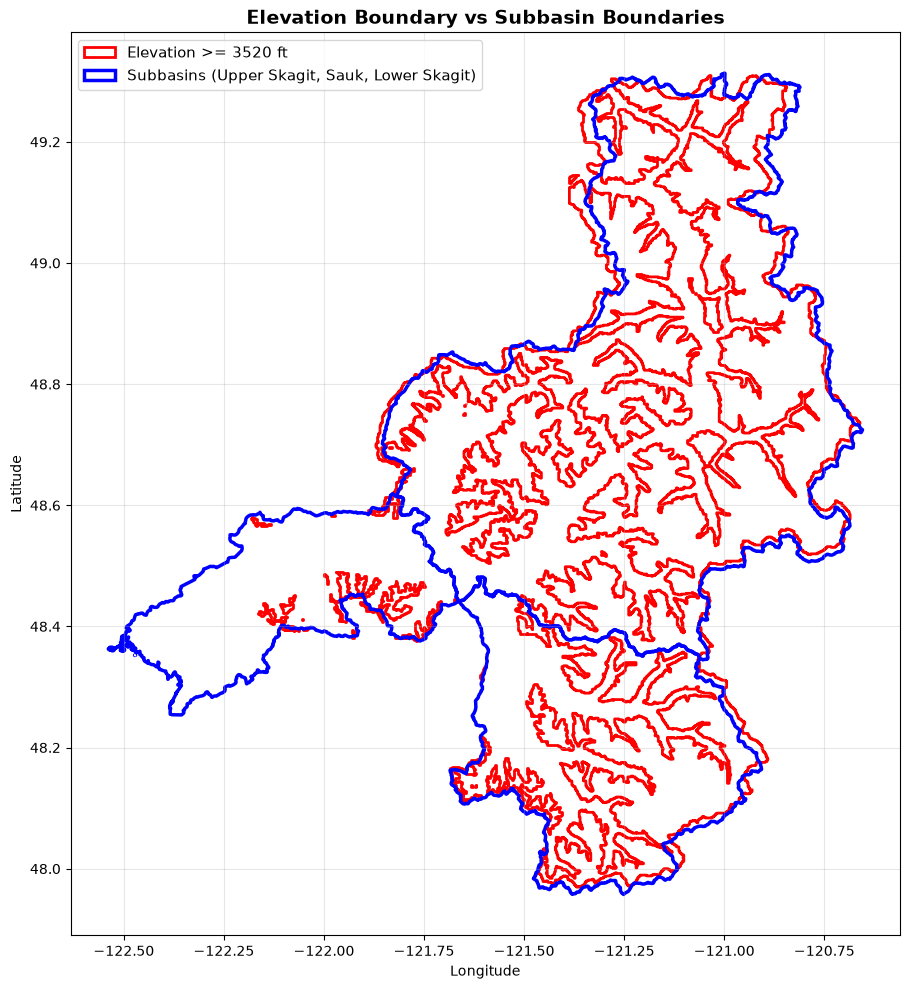

In [39]:
fig, ax = plt.subplots(figsize=(14, 10))

# Plot elevation boundary (red)
new_shapefile.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Elevation >= 3520 ft')

# Overlay original three subbasins (blue)
gdf_filtered.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2.5, label='Subbasins (Upper Skagit, Sauk, Lower Skagit)')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Elevation Boundary vs Subbasin Boundaries', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left') #, framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [1]:
# print(f"Filtered subbasin bounds: {bounds}")
# print(f"DEM shape: {dem.shape}")
# print(f"Expected full grid bounds from coordinates: {lons.min()}, {lons.max()}, {lats.min()}, {lats.max()}")


In [28]:
# import os
# import geopandas as gpd
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.patches import Patch
# from matplotlib.lines import Line2D

# # Configuration from spatial_plots script
# BASE_DIR = "/data0/nksp2/skagit/skagit_2/skagit-met"
# BOUNDARY_PATH = os.path.join(BASE_DIR, "data/GIS/SkagitBoundary.json")

# # Load shapefile
# print("Loading boundary from spatial_plots...")
# boundary_gdf = gpd.read_file(BOUNDARY_PATH).to_crs("EPSG:4326")

# # Get bounds from boundary shapefile
# bounds = boundary_gdf.total_bounds  # [minx, miny, maxx, maxy]
# print(f"Boundary bounds: {bounds}")

# # Load DEM and mask
# dem = np.loadtxt('/data0/hernanqd/instance_2021_data/instance_2021_DHSVM_3.1.3/arc/demsrtm150f.asc')
# mask = np.fromfile('/data0/hernanqd/instance_2021_data/instance_2021_DHSVM_3.1.3/arc/skagit.mask.bin',
#                     dtype=np.uint8).reshape(dem.shape)

# print(f"DEM shape: {dem.shape}")
# print(f"Mask shape: {mask.shape}")
# print(f"Mask unique values: {np.unique(mask)}")

# extent = [bounds[0], bounds[2], bounds[1], bounds[3]]

# # Create visualization
# fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# # Plot 1: DEM only
# im0 = axes[0].imshow(dem, cmap='terrain', extent=extent, origin='upper', aspect='auto')
# plt.colorbar(im0, ax=axes[0], label='Elevation (m)')
# axes[0].set_title('DEM', fontsize=12, fontweight='bold')

# # Plot 2: Mask only
# im1 = axes[1].imshow(mask, cmap='gray', extent=extent, origin='upper', aspect='auto')
# plt.colorbar(im1, ax=axes[1], label='Mask Value')
# axes[1].set_title('Mask (uint8)\nWhite=Inside Basin, Black=Outside', fontsize=12, fontweight='bold')

# # Plot 3: DEM with mask overlay and shapefile
# im2 = axes[2].imshow(dem, cmap='terrain', extent=extent, origin='upper', aspect='auto')
# mask_outside = np.ma.masked_where(mask != 0, mask)
# axes[2].imshow(mask_outside, cmap='Reds', alpha=0.8, extent=extent, origin='upper', aspect='auto')
# plt.colorbar(im2, ax=axes[2], label='Elevation (m)')

# # Overlay boundary shapefile (visible)
# boundary_gdf.plot(ax=axes[2], facecolor='none', edgecolor='blue', linewidth=3)
# axes[2].set_title('Verification: DEM + Mask + Boundary', fontsize=12, fontweight='bold')

# # Add legend
# legend_elements = [
#     Line2D([0], [0], color='w', linewidth=2.5, label='Colors = DEM elevation (terrain colormap)'),
#     Patch(facecolor='red', alpha=0.8, label='RED overlay = Outside basin (mask=0)'),
#     Line2D([0], [0], color='blue', linewidth=3, label='BLUE outline = Watershed boundary'),
# ]
# axes[2].legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.95)

# # Set labels
# for ax in axes:
#     ax.set_xlabel('Longitude')
#     ax.set_ylabel('Latitude')

# plt.tight_layout()
# plt.show()

# print("\n📊 Using spatial_plots boundary configuration")
# print("   • RED overlay should align with blue boundary edges")